<a href="https://colab.research.google.com/github/keirkwame/axionEmu/blob/main/Open_access_of_2e5_emulator_NN_tt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

# setting the seed for reproducibility
with tf.device('/device:GPU:1'):
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    np.random.seed(2)
    tf.random.set_seed(4)

#from google.colab import drive
#drive.mount('/content/drive')

2026-03-11 16:05:26.331399: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-11 16:05:26.331750: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-11 16:05:26.395463: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-11 16:05:26.536659: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-11 16:05:28.059161: W tensorflow/compiler/tf2

In [2]:
with tf.device('/device:GPU:1'):
    model_parameters = ['h', 
                        'tau_reio', 
                        'omega_b', 
                        'n_s', 
                        'ln10A_s', 
                        'omega_cdm',
                        'log10ma',
                        'omega_ax' 
                        ]

In [3]:
with tf.device('/device:GPU:1'):
    import pickle
    collection_list = []
    num_pkl_files = 21 #Set this number to loop over all the .pkl files that you generated
    c_ell_name = 'C_phi' #C_tt' #Pick which C_ell you would like to emulate

    for i in np.linspace(0, num_pkl_files-1,num_pkl_files):
        f = open('/home/keir/keir/data_C_ell_LH_ACT_DR6_TTTEEEPP_21_test_axion_'+str(int(i))+'.pkl', 'rb') #C_ell
        collection = pickle.load(f)
        f.close()
        print(len(collection[c_ell_name]))
        collection_list.append(collection)

    import random
    random.shuffle(collection_list)

1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1
1


In [11]:
frac_ax = np.zeros(21)

for i in range(0, 21):
    for j in range(1):
        if i < 30:
            ls = '-'
        else:
            ls = ':'
        omega_ax = collection_list[i]['params']['omega_ax'][j]
        omega_cdm = collection_list[i]['params']['omega_cdm'][j]
        frac_ax[i] = omega_ax / (omega_ax + omega_cdm)

print(frac_ax)
order_array = np.argsort(frac_ax)
print(order_array)


[5.50000004e-01 9.00000001e-01 1.00000000e+00 4.50000005e-01
 8.50000001e-01 7.50000002e-01 8.00000002e-01 5.00000005e-01
 2.00000008e-01 6.50000003e-01 5.00000095e-02 1.50000008e-01
 1.00000000e-08 2.50000008e-01 1.00000009e-01 3.00000007e-01
 3.50000006e-01 7.00000003e-01 4.00000006e-01 6.00000004e-01
 9.50000000e-01]
[12 10 14 11  8 13 15 16 18  3  7  0 19  9 17  5  6  4  1 20  2]


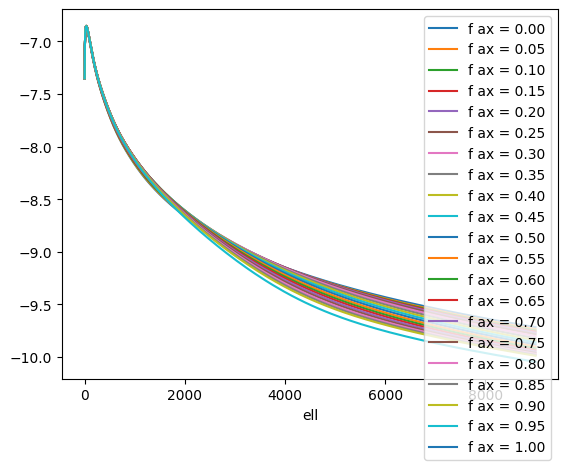

In [13]:
#for i in range(2):
#    print(collection_list[i])
for i in order_array: #range(0, 21):
    for j in range(1):
        if i < 30:
            ls = '-'
        else:
            ls = ':'
        omega_ax = collection_list[i]['params']['omega_ax'][j]
        omega_cdm = collection_list[i]['params']['omega_cdm'][j]
        frac_ax = omega_ax / (omega_ax + omega_cdm)
        plt.plot(np.log10(1. * collection_list[i]['C_phi'][j]), label='f ax = %.2f'%frac_ax, ls=ls) #* 1.e+7 / (2. * 3.14)
        plt.xlabel(r'ell')
        #plt.ylabel(r'C_l_te')
        #plt.title('Varying axion and LCDM parameters')
        plt.legend()
        #plt.savefig('C_l_bb_wiggles2.pdf')
        #print(collection_list[i]['problem_list'])


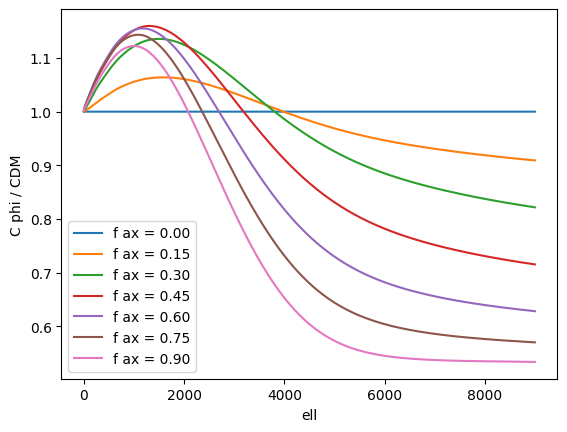

In [17]:
#for i in range(2):
#    print(collection_list[i])
for i in order_array[::3]: #range(0, 21):
    for j in range(1):
        if i < 30:
            ls = '-'
        else:
            ls = ':'
        omega_ax = collection_list[i]['params']['omega_ax'][j]
        omega_cdm = collection_list[i]['params']['omega_cdm'][j]
        frac_ax = omega_ax / (omega_ax + omega_cdm)
        plt.plot(collection_list[i]['C_phi'][j] / collection_list[order_array[0]]['C_phi'][j], label='f ax = %.2f'%frac_ax, ls=ls) #* 1.e+7 / (2. * 3.14)
        plt.xlabel(r'ell')
        plt.ylabel(r'C phi / CDM')
        #plt.title('Varying axion and LCDM parameters')
        plt.legend()
        #plt.savefig('C_l_bb_wiggles2.pdf')
        #print(collection_list[i]['problem_list'])

plt.savefig('C_phi_test_axion_24.pdf')


In [ ]:
cut_array = (parameters_list['ma'] < 1.e-25) * (parameters_list['omega_ax'] > 0.1)
print(cut_array.shape)
print(np.sum(cut_array))


In [ ]:
with tf.device('/device:GPU:1'):
    parameters_list = {}
    for key in collection['params']:
        parameters_list[key] = np.array([])

    C_list = []

    for i in range(num_pkl_files):
        para = collection_list[i]['params']
        C_list.extend(collection_list[i][c_ell_name])
        for key in para:
          parameters_list[key] = np.concatenate((parameters_list[key], para[key]))

    ell_range = np.linspace(2,3050,3049) #8600, 8599) #Specify here for what ell range you want to emulate
    print(ell_range)
    spectra_= np.log10(np.array(C_list)[:,:ell_range.shape[0]]) #/(7.4311*10**(12))/(ell_range*(ell_range+1)/(2.*np.pi)))
    print(spectra_.shape)

    #Remove nan spectra
    spectra_bool = np.array(np.sum(~np.isfinite(spectra_), axis=1), dtype=bool)
    print(spectra_bool)
    spectra_ = spectra_[~spectra_bool, :]
    for key in parameters_list.keys():
        parameters_list[key] = parameters_list[key][~spectra_bool]
        print(parameters_list[key].shape)
    print(spectra_.shape)

    #Remove bad spectra
    cut_array = (parameters_list['ma'] < 1.e-25) * (parameters_list['omega_ax'] > 0.1) #0.1
    print(np.sum(cut_array))
    spectra_ = spectra_[~cut_array, :]
    for key in parameters_list.keys():
        parameters_list[key] = parameters_list[key][~cut_array]
        print(parameters_list[key].shape)
    print(spectra_.shape)

    #Remove bad spectra #2
    cut_array2 = (parameters_list['ma'] < 5.e-26) * (parameters_list['omega_ax'] > 0.03)
    print(np.sum(cut_array2))
    spectra_ = spectra_[~cut_array2, :]
    for key in parameters_list.keys():
        parameters_list[key] = parameters_list[key][~cut_array2]
        print(parameters_list[key].shape)
    print(spectra_.shape)

    cut_off = 120000 #This splits the dataset into training and test sets at this cut-off number
    import copy
    training_parameters_ = copy.deepcopy(parameters_list)
    h_0 = training_parameters_['H_0'][:cut_off]/100
    ln10_10A_s = np.log(training_parameters_['A_s'][:cut_off]*10**10)
    ma_mass = np.array(training_parameters_['ma'][:cut_off]*10**32,dtype='float64')
    ma_mass = np.log10(ma_mass) #We define axion mass as the logarithmic difference to -32, e.g., 10^-27 eV is 5
    training_parameters = dict()
    training_parameters['omega_b'] = training_parameters_['omega_b'][:cut_off]
    training_parameters['omega_cdm'] = training_parameters_['omega_cdm'][:cut_off]
    training_parameters['h'] = h_0
    training_parameters['tau_reio'] = training_parameters_['tau_reio'][:cut_off]
    training_parameters['n_s'] = training_parameters_['n_s'][:cut_off]
    training_parameters['ln10A_s'] = ln10_10A_s
    training_parameters['log10ma'] = ma_mass
    training_parameters['omega_ax'] = training_parameters_['omega_ax'][:cut_off]

    test_parameters_ = copy.deepcopy(parameters_list)
    h_0 = test_parameters_['H_0'][cut_off:]/100
    ln10_10A_s = np.log(test_parameters_['A_s'][cut_off:]*10**10)
    ma_mass = np.array(test_parameters_['ma'][cut_off:]*10**32, dtype = 'float64')
    ma_mass = np.log10(ma_mass)
    test_parameters = dict()
    test_parameters['omega_b'] = test_parameters_['omega_b'][cut_off:]
    test_parameters['omega_cdm'] = test_parameters_['omega_cdm'][cut_off:]
    test_parameters['h'] = h_0
    test_parameters['tau_reio'] = test_parameters_['tau_reio'][cut_off:]
    test_parameters['n_s'] = test_parameters_['n_s'][cut_off:]
    test_parameters['ln10A_s'] = ln10_10A_s
    test_parameters['omega_ax'] = test_parameters_['omega_ax'][cut_off:]
    test_parameters['log10ma'] = ma_mass

    training_log_spectra = spectra_[:cut_off,:]
    testing_spectra = 10. ** spectra_[cut_off:,:]
    print('number of training spectra: ', training_log_spectra.shape)
    print('number of testing spectra: ', testing_spectra.shape)


In [ ]:
%matplotlib inline
plt.plot(ell_range, (training_log_spectra[0])) #* ell_range * (ell_range + 1) / 2. / np.pi)
plt.plot(ell_range, (training_log_spectra[-1])) #* ell_range * (ell_range + 1) / 2. / np.pi)


In [ ]:
with tf.device('/device:GPU:1'):
    test_collection = {}
    test_collection['training_parameters'] = training_parameters
    test_collection['test_parameters'] = test_parameters
    test_collection['training_log_spectra'] = training_log_spectra
    test_collection['testing_spectra'] = testing_spectra
    import pickle
    f = open('data_training_test_ACT_DR6_C_phi_200k_axion_cut2_ell3000_deeper.pkl', 'wb')
    pickle.dump(test_collection, f)
    f.close()


In [ ]:
##Only for Google Colab
!git clone https://github.com/keirkwame/axionEmu.git

In [ ]:
# instantiate NN class
with tf.device('/device:GPU:1'): # ensures we are running on a GPU
    from axionEmu.cosmopower import cosmopower_NN
    cp_nn = cosmopower_NN(parameters=model_parameters, 
                      modes=ell_range, 
                      n_hidden = [1024, 512, 256, 128, 64, 32, 16], #[512, 512, 512,512], # 4 hidden layers, each with 512 nodes
                      verbose=True, # useful to understand the different steps in initialisation and training
                      )


In [ ]:
with tf.device('/device:GPU:1'): # ensures we are running on a GPU
    # train
    cp_nn.train(training_parameters=training_parameters,
                training_features=training_log_spectra,
                filename_saved_model='Phi_NL_NN_axion_emulator_ACT_DR6_200k_cut2_ell3000_deeper', #Give a name to the emulator file
                # cooling schedule
                validation_split=0.1,
                learning_rates=[1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7],
                batch_sizes= [1024,1024,1024,1024,1024, 1024],
                gradient_accumulation_steps = [1, 1, 1, 1, 1, 1],
                # early stopping set up
                patience_values = [100,100,100,100,100,100],
                max_epochs = [1000,1000,1000,1000,1000,1000],
                )


In [ ]:
from axionEmu.cosmopower import cosmopower_NN


In [ ]:
with tf.device('/device:GPU:1'): # ensures we are running on a GPU
    cp_nn = cosmopower_NN(restore=True, 
                          restore_filename='Phi_NL_NN_axion_emulator_ACT_DR6_200k_cut2_ell3000_deeper',
                          )


In [ ]:
with tf.device('/device:GPU:1'): # ensures we are running on a GPU
    predicted_testing_spectra = cp_nn.ten_to_predictions_np(test_parameters)
    import matplotlib.pyplot as plt
    from matplotlib import gridspec
    plt.rcParams['font.size'] = '20'
    fig, ax = plt.subplots(nrows=10, ncols=1, figsize=(50,30))
    for i in range(10):
        pred = predicted_testing_spectra[i] #*ell_range*(ell_range+1)/(2.*np.pi)
        true = testing_spectra[i] #*ell_range*(ell_range+1)/(2.*np.pi)
        ax[i].plot(ell_range, np.log10(true), 'blue', label = 'Original')
        ax[i].plot(ell_range, np.log10(pred), 'red', label = 'NN reconstructed', linestyle='--')
        #ax[i].set_yscale('log')
        ax[i].set_xlabel('$\ell$', fontsize='x-large')
        ax[i].set_ylabel('$C_\ell$', fontsize='x-large')
        ax[i].legend(fontsize=15)
    #plt.savefig('examples_reconstruction_Phi_axion_ACT_DR6_200k_cut2_ell3000_deeper.pdf')


In [ ]:
#Make a plot of the axion mass -- omega_axion training/test samples

print(np.sum(np.isnan(spectra_)) / np.size(spectra_))
print(parameters_list.keys())
for i in range(spectra_.shape[0]):
    if np.sum(~np.isnan(spectra_[i])):
        plt.scatter(np.log10(parameters_list['ma'][i]), parameters_list['omega_ax'][i])


In [ ]:
##Only for Google Colab
!git clone https://github.com/simonsobs/so_noise_models

In [ ]:
with tf.device('/device:GPU:1'): # ensures we are running on a GPU
    # load noise models from the SO noise repo
    '''noise_levels_load = np.loadtxt('./so_noise_models/LAT_comp_sep_noise/v3.1.0/SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_CMB.txt')
    conv_factor = (2.7255e6)**2

    ells = noise_levels_load[:, 0]
    SO_TT_noise = noise_levels_load[:, 1][:np.max(ell_range)+1-40] / conv_factor ##6001-40
    new_ells = ells[:np.max(ell_range)+1-40] ##6001-40

    f_sky = 0.4'''
    prefac = 1. #np.sqrt(2/(f_sky*(2*new_ells+1)))

    ##Cut off some spectra
    #print(new_ells)
    #print(prefac.shape, testing_spectra.shape, SO_TT_noise.shape)
    #testing_spectra = testing_spectra[:6001-40]

    denominator = prefac*testing_spectra[:, :]  # use all of them #+SO_TT_noise #38:
    diff = np.abs((predicted_testing_spectra[:, :] - testing_spectra[:, :])/(denominator))

    # Compute percentiles
    percentiles = np.zeros((4, diff.shape[1]))

    percentiles[0] = np.percentile(diff, 68, axis = 0)
    percentiles[1] = np.percentile(diff, 95, axis = 0)
    percentiles[2] = np.percentile(diff, 99, axis = 0)
    percentiles[3] = np.percentile(diff, 99.9, axis = 0)

    plt.figure(figsize=(12, 9))
    plt.fill_between(ell_range, 0, percentiles[2,:], color = 'salmon', label = '99%', alpha=0.8)
    plt.fill_between(ell_range, 0, percentiles[1,:], color = 'red', label = '95%', alpha = 0.7)
    plt.fill_between(ell_range, 0, percentiles[0,:], color = 'darkred', label = '68%', alpha = 1)

    # plt.ylim(0, 0.2)

    plt.legend(frameon=False, fontsize=30, loc='upper left')
    plt.ylabel(r'$\frac{| C_{\ell, \rm{emulated}}^{\rm{Phi}} - C_{\ell, \rm{true}}^{\rm{Phi}}|} {C_{\ell, \rm{CMB}}^{\rm{Phi}}}$', fontsize=50)
    plt.xlabel(r'$\ell$',  fontsize=50)
    plt.xscale('linear')

    plt.axhline(y=0.01)
    #plt.axvline(x=np.log10(40))
    #plt.xscale('log')

    ax = plt.gca()
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

    plt.setp(ax.get_xticklabels(), fontsize=25)
    plt.setp(ax.get_yticklabels(), fontsize=25)
    plt.tight_layout()
    #plt.savefig('./accuracy_emu_Phi_ACT_DR6_axion_200k_cut2_ell3000_deeper.pdf')

    diff_=np.sum(diff,axis = 1)
    print('diff_.shape is ', diff_.shape)
    sort_index = np.argsort(diff_)
    bad_params = dict()
    for key in test_parameters:
        bad_params[key] = []
    for i in sort_index[len(sort_index)-100:]:
        for key in test_parameters:
            bad_params[key].append(test_parameters[key][i])
    fig, ax = plt.subplots(nrows=1, ncols=8, figsize=(50,10))
    for i in range(8):
        pa =list(test_parameters.keys())[i]
        h = bad_params[pa]
        ax[i].plot(h, 'o')
        ax[i].set_ylabel(pa, fontsize='x-large')
    #plt.savefig('worst_params_Phi_ACT_DR6_axion_200k_cut2_ell3000_deeper.pdf')


In [ ]:
print(10.**(6.6-32))


In [ ]:
print(test_parameters)


In [ ]:
f_ax = np.array([1.e-8, 0.01, 0.03, 0.05, 0.07])
#f_ax = np.array([1.e-6, 0.01, 0.1, 0.3, 0.5])

test_parameters2 = {'omega_b': np.array([0.022126,] * 5),
                   'omega_cdm': np.array([0.12068,] * 5) * (1. - f_ax),
                   'h': np.array([0.6686,] * 5),
                   'tau_reio': np.array([0.0523,] * 5),
                   'n_s': np.array([0.9635,] * 5),
                   'ln10A_s': np.array([3.0413,] * 5),
                   'omega_ax': np.array([0.12068,] * 5) * f_ax,
                   'log10ma': np.array([8.,] * 5)}


In [ ]:
predicted_testing_spectra2 = cp_nn.ten_to_predictions_np(test_parameters2)


In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 9))
for i, predicted_testing_spectrum in enumerate(predicted_testing_spectra2):
    axes[0].plot(ell_range, predicted_testing_spectrum, label='omegaax = %.4f'%test_parameters2['omega_ax'][i])
    axes[1].plot(ell_range, predicted_testing_spectrum / predicted_testing_spectra2[0])
axes[1].set_xlabel('L')
axes[0].set_ylabel('Lensing power')
axes[1].set_ylabel('Ratio to LCDM')
axes[0].set_xscale('log')
axes[1].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()
plt.show()


In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 9))
for i in np.array([2, 1, 0, 4, 3]):
    predicted_testing_spectrum = collection_list[i]['C_phi'][0][:ell_range.shape[0]]
    axes[0].plot(ell_range, predicted_testing_spectrum, label='omegaax = %.4f'%collection_list[i]['params']['omega_ax'][0])
    axes[1].plot(ell_range, predicted_testing_spectrum / collection_list[2]['C_phi'][0][:ell_range.shape[0]])
axes[1].set_xlabel('L')
axes[0].set_ylabel('Lensing power')
axes[1].set_ylabel('Ratio to LCDM')
axes[0].set_xscale('log')
axes[1].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()
#plt.show()
fig.savefig('lensing_power_test_AxiECAMB_higher_accuracy.pdf')


In [ ]:
print(ell_range.shape)
